# ResNet-34 UNet Baseline for Keratitis AS-OCT Segmentation

**Purpose:** Establish a UNet baseline to quantify ScLNet's architectural value-add  
**Model:** ResNet-34 encoder + standard UNet decoder (no multi-scale pyramid, no DAC, no boundary decoder)  
**Dataset:** AIDK — An AS-OCT Image Dataset for Deep Learning-Enabled Segmentation (Sun et al., Scientific Data 2024)  

---

## Why This Baseline?

ScLNet adds three innovations over a standard UNet:
1. **Multi-scale input pyramid** (full, ½, ¼, ⅛ resolutions)
2. **Dense Atrous Convolution (DAC) blocks** for multi-scale context
3. **Dual-task decoder** — boundary prediction feeds into segmentation

This notebook uses the **same ResNet-34 backbone, same loss function, same data pipeline,
and same hyperparameters** as the ScLNet notebook. The ONLY difference is the decoder
architecture — isolating exactly what ScLNet's innovations contribute.

### Expected Outcome
If ScLNet outperforms this UNet, its architectural innovations are justified for this dataset.
If performance is similar, the added complexity may not be warranted.

## 0 — Install & Import Dependencies

In [1]:
# Uncomment and run if packages are not yet installed
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
# !pip install albumentations opencv-python-headless scikit-learn scipy matplotlib tqdm

In [2]:
import os
import json
import glob
import random
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from collections import OrderedDict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from scipy.spatial.distance import directed_hausdorff
from tqdm.auto import tqdm

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## 1 — Configuration

**IMPORTANT:** These settings match the ScLNet epoch-67 run exactly for a fair comparison.
To switch to the recommended "both subsets, no iris" config, change `USE_SUBSET` and `INCLUDE_IRIS`.

In [3]:
# ============================================================
# >>>  SET YOUR DATASET PATHS HERE  <<<
# ============================================================

DATASET_ROOT = "/kaggle/input/datasets/ianxlee/aidk-dataset/AIDK_Dataset"   # <-- CHANGE THIS

# Which subset to use: "partial", "full", or "both"
# Epoch-67 ScLNet used "full" + INCLUDE_IRIS=True — keep this for direct comparison.
# Recommended alternative: USE_SUBSET="both", INCLUDE_IRIS=False (maximises lesion patient diversity)
USE_SUBSET = "full"

# Whether to include iris as a segmentation class (only available in full-frame)
INCLUDE_IRIS = True

# ============================================================
# Training Hyperparameters (IDENTICAL to ScLNet notebook)
# ============================================================
IMG_SIZE        = 512        # Resize all images to 512x512
NUM_CLASSES     = 3          # 0=background, 1=cornea, 2=lesion  (set to 4 if INCLUDE_IRIS)
BATCH_SIZE      = 4          # Same as ScLNet run
NUM_EPOCHS      = 100        # Paper trains for 100 epochs
INIT_LR         = 0.01       # Initial learning rate
LR_STEP         = 20         # Reduce LR every 20 epochs
LR_GAMMA        = 0.1        # Multiply LR by 0.1
EARLY_STOP      = 50         # Stop if no improvement for 50 epochs
NUM_WORKERS     = 4          # DataLoader workers
VAL_SPLIT       = 0.2        # 20% validation
TEST_SPLIT      = 0.1        # 10% test

if INCLUDE_IRIS:
    NUM_CLASSES = 4  # 0=bg, 1=cornea, 2=lesion, 3=iris

## 2 — Dataset: Loading & Parsing the AIDK Data

Identical to the ScLNet notebook. We still generate boundary masks so the dataset class
can be reused, but the UNet model ignores them.

In [4]:
def collect_samples(dataset_root: str, subset: str = "both"):
    """Collect (image_path, annotation_path, is_fullframe) tuples."""
    samples = []
    subsets = []
    if subset in ("partial", "both"):
        subsets.append(("Partial-frame_Dataset", False))
    if subset in ("full", "both"):
        subsets.append(("Full-frame_Dataset", True))

    for folder_name, is_full in subsets:
        img_dir  = os.path.join(dataset_root, folder_name, "Original_AS-OCT_Images")
        ann_dir  = os.path.join(dataset_root, folder_name, "Experts_Annotations")
        if not os.path.isdir(img_dir):
            print(f"WARNING: {img_dir} not found — skipping.")
            continue
        bmp_files = sorted(glob.glob(os.path.join(img_dir, "*.bmp")),
                           key=lambda p: int(os.path.splitext(os.path.basename(p))[0]))
        for img_path in bmp_files:
            stem = os.path.splitext(os.path.basename(img_path))[0]
            ann_path = os.path.join(ann_dir, f"{stem}.json")
            if os.path.isfile(ann_path):
                samples.append((img_path, ann_path, is_full))
            else:
                print(f"WARNING: Missing annotation for {img_path}")
    print(f"Collected {len(samples)} samples ({subset} subset).")
    return samples

all_samples = collect_samples(DATASET_ROOT, USE_SUBSET)

Collected 768 samples (full subset).


In [5]:
def parse_labelme_json(json_path: str, img_h: int, img_w: int,
                       include_iris: bool = False):
    """Parse a LabelMe JSON annotation into a segmentation mask.

    Returns:
        seg_mask : np.ndarray (H, W) with class indices
                   0 = background, 1 = cornea, 2 = lesion, 3 = iris (if included)
    """
    with open(json_path, "r") as f:
        data = json.load(f)

    seg_mask = np.zeros((img_h, img_w), dtype=np.uint8)

    # Map label names -> class indices  (order matters: paint cornea first,
    # then lesion on top so lesion overwrites cornea where they overlap)
    label_map = {}
    for shape in data.get("shapes", []):
        lbl = shape["label"].strip().lower()
        if "cornea" in lbl:
            label_map.setdefault("cornea", []).append(shape)
        elif "lesion" in lbl or "keratitis" in lbl:
            label_map.setdefault("lesion", []).append(shape)
        elif "iris" in lbl and include_iris:
            label_map.setdefault("iris", []).append(shape)

    # Draw order: cornea (1) -> iris (3) -> lesion (2)  (lesion highest priority)
    draw_order = [("cornea", 1)]
    if include_iris:
        draw_order.append(("iris", 3))
    draw_order.append(("lesion", 2))

    for name, cls_idx in draw_order:
        for shape in label_map.get(name, []):
            pts = np.array(shape["points"], dtype=np.int32)
            if pts.shape[0] >= 3:
                cv2.fillPoly(seg_mask, [pts], cls_idx)

    return seg_mask


def make_boundary_mask(seg_mask: np.ndarray, thickness: int = 2):
    """Derive boundary mask from segmentation mask via morphological gradient."""
    boundary = np.zeros_like(seg_mask, dtype=np.uint8)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (thickness, thickness))
    for cls_id in range(1, seg_mask.max() + 1):
        cls_binary = (seg_mask == cls_id).astype(np.uint8)
        dilated = cv2.dilate(cls_binary, kernel)
        eroded  = cv2.erode(cls_binary, kernel)
        edge = dilated - eroded
        boundary[edge > 0] = cls_id
    return boundary

## 3 — Dataset Class & Augmentations

In [6]:
class AIDKDataset(Dataset):
    """AIDK Keratitis AS-OCT dataset.

    Returns (image, seg_mask, boundary_mask) for compatibility with ScLNet pipeline.
    The UNet model only uses image and seg_mask.
    """

    def __init__(self, samples, img_size=512, include_iris=False,
                 transform=None, boundary_thickness=2):
        self.samples = samples
        self.img_size = img_size
        self.include_iris = include_iris
        self.transform = transform
        self.boundary_thickness = boundary_thickness

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, ann_path, is_full = self.samples[idx]

        # Load image
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w = image.shape[:2]

        # Parse annotation -> segmentation mask
        seg_mask = parse_labelme_json(ann_path, h, w,
                                     include_iris=(self.include_iris and is_full))

        # Resize
        image    = cv2.resize(image, (self.img_size, self.img_size),
                              interpolation=cv2.INTER_LINEAR)
        seg_mask = cv2.resize(seg_mask, (self.img_size, self.img_size),
                              interpolation=cv2.INTER_NEAREST)

        # Apply augmentations
        if self.transform:
            augmented = self.transform(image=image, mask=seg_mask)
            image    = augmented["image"]
            seg_mask = augmented["mask"]

        # Derive boundary mask from (augmented) segmentation mask
        if isinstance(seg_mask, torch.Tensor):
            seg_np = seg_mask.numpy()
        else:
            seg_np = seg_mask
        boundary_mask = make_boundary_mask(seg_np.astype(np.uint8),
                                          self.boundary_thickness)

        # Convert to tensors
        if not isinstance(image, torch.Tensor):
            image = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0
        else:
            image = image.float() / 255.0 if image.max() > 1 else image.float()

        seg_mask = torch.from_numpy(seg_np).long()
        boundary_mask = torch.from_numpy(boundary_mask).long()

        return image, seg_mask, boundary_mask

In [7]:
# Augmentations matching the ScLNet paper (updated for albumentations v2.x)
train_transform = A.Compose([
    A.VerticalFlip(p=0.5),
    A.Affine(
        translate_percent={"x": (-0.1, 0.1), "y": (-0.1, 0.1)},  # +/-10% translation
        scale=(0.9, 1.1),           # scale 0.9-1.1
        rotate=(-10, 10),           # +/-10 degrees
        border_mode=cv2.BORDER_CONSTANT,
        fill=0,
        fill_mask=0,
        p=0.7,
    ),
    A.GaussNoise(std_range=(0.009, 0.02), p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.3),
])

val_transform = None  # No augmentation for validation/test

In [8]:
# Train / Val / Test split (IDENTICAL random state = same split)
train_val_samples, test_samples = train_test_split(
    all_samples, test_size=TEST_SPLIT, random_state=SEED
)
train_samples, val_samples = train_test_split(
    train_val_samples, test_size=VAL_SPLIT / (1 - TEST_SPLIT), random_state=SEED
)

print(f"Train: {len(train_samples)} | Val: {len(val_samples)} | Test: {len(test_samples)}")

train_ds = AIDKDataset(train_samples, IMG_SIZE, INCLUDE_IRIS, train_transform)
val_ds   = AIDKDataset(val_samples,   IMG_SIZE, INCLUDE_IRIS, val_transform)
test_ds  = AIDKDataset(test_samples,  IMG_SIZE, INCLUDE_IRIS, val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=1, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

Train: 537 | Val: 154 | Test: 77


## 4 — Model Architecture: ResNet-34 UNet

Standard UNet with a ResNet-34-style encoder. Key differences from ScLNet:
- **No multi-scale input pyramid** — single-resolution input only
- **No DAC blocks** — standard convolutions throughout
- **No boundary decoder** — single-task segmentation only
- **No feature subtraction** — standard skip connections
- **Same channel widths**: [64, 128, 256, 512, 512] to match ScLNet's encoder

In [9]:
# ---------------------------------------------------------------
# Building blocks (same ResBlock as ScLNet for fair comparison)
# ---------------------------------------------------------------

class ResBlock(nn.Module):
    """Residual block: 1x1 conv shortcut + two 3x3 convs."""
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride, 1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, 1, 1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.relu  = nn.ReLU(inplace=True)
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, stride, bias=False),
            nn.BatchNorm2d(out_ch),
        ) if (in_ch != out_ch or stride != 1) else nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.relu(out + identity)

In [10]:
# ---------------------------------------------------------------
# ResNet-34 Encoder (same backbone as ScLNet, minus DAC & multi-scale)
# ---------------------------------------------------------------

class ResNet34Encoder(nn.Module):
    """Standard ResNet-34-style encoder without multi-scale input or DAC blocks."""

    def __init__(self, in_channels=3):
        super().__init__()
        self.channels = [64, 128, 256, 512, 512]
        n_blocks      = [3,  4,   6,   3,   3]

        # Initial conv (same stem as ScLNet)
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 64, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1),
        )

        # Encoder stages (stacked ResBlocks — same structure as ScLNet)
        self.stages = nn.ModuleList()
        in_ch = 64
        for i, (out_ch, n) in enumerate(zip(self.channels, n_blocks)):
            blocks = []
            for j in range(n):
                stride = 2 if (j == 0 and i > 0) else 1
                blocks.append(ResBlock(in_ch if j == 0 else out_ch, out_ch, stride))
            self.stages.append(nn.Sequential(*blocks))
            in_ch = out_ch

    def forward(self, x):
        f0 = self.stem(x)          # (B, 64, H/4, W/4)
        f0 = self.stages[0](f0)    # Stage 0: (B, 64, H/4, W/4)

        features = [f0]
        prev = f0
        for i in range(1, 5):
            f = self.stages[i](prev)  # Each stage downsamples by 2
            features.append(f)
            prev = f

        return features  # 5 levels: [f0, f1, f2, f3, f4]

In [11]:
# ---------------------------------------------------------------
# UNet Decoder
# ---------------------------------------------------------------

class UNetDecoderBlock(nn.Module):
    """Standard UNet decoder stage: upsample -> concat skip -> ResBlocks."""
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.block = nn.Sequential(
            ResBlock(in_ch + skip_ch, out_ch),
            ResBlock(out_ch, out_ch),
        )

    def forward(self, x, skip):
        x = self.up(x)
        # Align spatial dims if needed
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:], mode="bilinear",
                              align_corners=False)
        return self.block(torch.cat([x, skip], dim=1))


class UNetDecoder(nn.Module):
    """Standard UNet decoder — no boundary skip connections."""
    def __init__(self, enc_channels, num_classes):
        super().__init__()
        ch = enc_channels  # [64, 128, 256, 512, 512]
        self.dec4 = UNetDecoderBlock(ch[4], ch[3], ch[3])
        self.dec3 = UNetDecoderBlock(ch[3], ch[2], ch[2])
        self.dec2 = UNetDecoderBlock(ch[2], ch[1], ch[1])
        self.dec1 = UNetDecoderBlock(ch[1], ch[0], ch[0])

        self.final_up = nn.Upsample(scale_factor=4, mode="bilinear", align_corners=False)
        self.head = nn.Conv2d(ch[0], num_classes, 1)

    def forward(self, features):
        # features[0..4]: encoder features (shallow -> deep)
        d4 = self.dec4(features[4], features[3])
        d3 = self.dec3(d4, features[2])
        d2 = self.dec2(d3, features[1])
        d1 = self.dec1(d2, features[0])

        out = self.final_up(d1)
        return self.head(out)

In [12]:
# ---------------------------------------------------------------
# Full UNet Model
# ---------------------------------------------------------------

class ResNet34UNet(nn.Module):
    """ResNet-34 UNet baseline.

    Same backbone as ScLNet but with a standard single-task decoder.
    No multi-scale pyramid, no DAC blocks, no boundary decoder.
    """

    def __init__(self, in_channels=3, num_classes=3):
        super().__init__()
        self.encoder = ResNet34Encoder(in_channels)
        self.decoder = UNetDecoder(self.encoder.channels, num_classes)

    def forward(self, x):
        features = self.encoder(x)
        seg_out = self.decoder(features)
        return seg_out


# Quick test
_model = ResNet34UNet(in_channels=3, num_classes=NUM_CLASSES).to(DEVICE)
_dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
with torch.no_grad():
    _seg = _model(_dummy)
print(f"Seg output: {_seg.shape}")

total_params = sum(p.numel() for p in _model.parameters())
print(f"Total parameters: {total_params / 1e6:.2f} M")
del _model, _dummy, _seg
torch.cuda.empty_cache()

Seg output: torch.Size([1, 4, 512, 512])
Total parameters: 52.94 M


## 5 — Loss Function

Same **per-class independent log-Dice loss** as ScLNet — the key fix that got
lesion DSC off zero. No boundary loss component since UNet is single-task.

In [13]:
class LogDiceLoss(nn.Module):
    """Log-Dice loss for multi-class segmentation.

    Computes per-class Dice independently, averages, then takes -log.
    This is the per-class independent formulation that was critical
    for getting lesion DSC > 0.
    """
    def __init__(self, num_classes, smooth=1.0):
        super().__init__()
        self.num_classes = num_classes
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)  # (B, C, H, W)

        # One-hot encode targets
        targets_oh = F.one_hot(targets, self.num_classes)  # (B, H, W, C)
        targets_oh = targets_oh.permute(0, 3, 1, 2).float()  # (B, C, H, W)

        dice_per_class = []
        for c in range(self.num_classes):
            p = probs[:, c].reshape(-1)
            g = targets_oh[:, c].reshape(-1)
            intersection = (p * g).sum()
            dice = (2.0 * intersection + self.smooth) / \
                   (p.pow(2).sum() + g.pow(2).sum() + self.smooth)
            dice_per_class.append(dice)

        dice_avg = torch.stack(dice_per_class).mean()
        return -torch.log(dice_avg + 1e-8)

## 6 — Evaluation Metrics

Identical to ScLNet: **DSC**, **IoU**, **MCC**, **Precision**, **Hausdorff Distance**.

In [14]:
def compute_metrics(pred: np.ndarray, gt: np.ndarray, num_classes: int):
    """Compute per-class DSC, IoU, MCC, Precision, HD."""
    results = {}
    for c in range(1, num_classes):  # Skip background
        p = (pred == c).astype(np.float32)
        g = (gt == c).astype(np.float32)

        tp = (p * g).sum()
        fp = (p * (1 - g)).sum()
        fn = ((1 - p) * g).sum()
        tn = ((1 - p) * (1 - g)).sum()

        # DSC
        dsc = (2 * tp) / (2 * tp + fp + fn + 1e-8)

        # IoU
        iou = tp / (tp + fp + fn + 1e-8)

        # MCC
        denom = np.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn) + 1e-8)
        mcc = (tp * tn - fp * fn) / denom

        # Precision
        precision = tp / (tp + fp + 1e-8)

        # Hausdorff Distance
        p_pts = np.argwhere(p > 0)
        g_pts = np.argwhere(g > 0)
        if len(p_pts) > 0 and len(g_pts) > 0:
            hd = max(directed_hausdorff(p_pts, g_pts)[0],
                     directed_hausdorff(g_pts, p_pts)[0])
        elif len(p_pts) == 0 and len(g_pts) == 0:
            hd = 0.0
        else:
            hd = float("inf")

        results[c] = {
            "DSC": float(dsc), "IoU": float(iou), "MCC": float(mcc),
            "Precision": float(precision), "HD": float(hd),
        }
    return results


CLASS_NAMES = {1: "Cornea", 2: "Lesion"}
if INCLUDE_IRIS:
    CLASS_NAMES[3] = "Iris" 

## 7 — Training Loop

In [15]:
model = ResNet34UNet(in_channels=3, num_classes=NUM_CLASSES).to(DEVICE)
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs via DataParallel")
    model = nn.DataParallel(model)

criterion = LogDiceLoss(NUM_CLASSES)
optimizer = optim.SGD(model.parameters(), lr=INIT_LR, momentum=0.9, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP, gamma=LR_GAMMA)

# Mixed precision: cuts GPU memory ~40-50% with negligible effect on accuracy
scaler = torch.cuda.amp.GradScaler()
print("Mixed precision (AMP) enabled")

Using 2 GPUs via DataParallel
Mixed precision (AMP) enabled


/tmp/ipykernel_24/2535739376.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [16]:
def train_one_epoch(model, loader, criterion, optimizer, device, scaler):
    model.train()
    running_loss = 0.0
    for images, seg_masks, _bnd_masks in tqdm(loader, desc="Train", leave=False):
        images    = images.to(device)
        seg_masks = seg_masks.to(device)

        # Mixed precision forward pass
        with torch.cuda.amp.autocast():
            seg_out = model(images)
            if seg_out.shape[2:] != seg_masks.shape[1:]:
                seg_out = F.interpolate(seg_out, size=seg_masks.shape[1:],
                                       mode="bilinear", align_corners=False)
            loss = criterion(seg_out, seg_masks)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)

    return running_loss / len(loader.dataset)


@torch.no_grad()
def validate(model, loader, criterion, device, num_classes):
    model.eval()
    running_loss = 0.0
    all_metrics = {c: {"DSC": [], "IoU": []} for c in range(1, num_classes)}

    for images, seg_masks, _bnd_masks in tqdm(loader, desc="Val", leave=False):
        images    = images.to(device)
        seg_masks = seg_masks.to(device)

        with torch.cuda.amp.autocast():
            seg_out = model(images)
            if seg_out.shape[2:] != seg_masks.shape[1:]:
                seg_out = F.interpolate(seg_out, size=seg_masks.shape[1:],
                                       mode="bilinear", align_corners=False)
            loss = criterion(seg_out, seg_masks)

        running_loss += loss.item() * images.size(0)

        preds = seg_out.argmax(dim=1).cpu().numpy()
        gts   = seg_masks.cpu().numpy()
        for i in range(preds.shape[0]):
            m = compute_metrics(preds[i], gts[i], num_classes)
            for c in m:
                all_metrics[c]["DSC"].append(m[c]["DSC"])
                all_metrics[c]["IoU"].append(m[c]["IoU"])

    avg_loss = running_loss / len(loader.dataset)
    summary = {}
    for c in all_metrics:
        summary[c] = {
            "DSC": np.mean(all_metrics[c]["DSC"]),
            "IoU": np.mean(all_metrics[c]["IoU"]),
        }
    return avg_loss, summary

In [17]:
# -- Main training loop --
best_val_loss = float("inf")
epochs_no_improve = 0
history = {"train_loss": [], "val_loss": [], "val_dsc": []}

SAVE_PATH = "unet_baseline_best.pth"

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}  |  LR: {scheduler.get_last_lr()[0]:.6f}")

    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE, scaler)
    val_loss, val_metrics = validate(model, val_loader, criterion, DEVICE, NUM_CLASSES)
    scheduler.step()

    # Average DSC across foreground classes
    avg_dsc = np.mean([val_metrics[c]["DSC"] for c in val_metrics])

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_dsc"].append(avg_dsc)

    metric_str = "  ".join(
        f"{CLASS_NAMES.get(c, c)}: DSC={val_metrics[c]['DSC']:.4f} IoU={val_metrics[c]['IoU']:.4f}"
        for c in val_metrics
    )
    print(f"  Train Loss: {train_loss:.4f}  |  Val Loss: {val_loss:.4f}  |  Avg DSC: {avg_dsc:.4f}")
    print(f"  {metric_str}")

    # Checkpointing
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        state = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
        torch.save(state, SAVE_PATH)
        print(f"  >> Saved best model (val_loss={val_loss:.4f})")
    else:
        epochs_no_improve += 1

    # Early stopping
    if epochs_no_improve >= EARLY_STOP:
        print(f"\nEarly stopping after {EARLY_STOP} epochs without improvement.")
        break

print("\nTraining complete.")


Epoch 1/100  |  LR: 0.010000


Train:   0%|          | 0/134 [00:00<?, ?it/s]

/tmp/ipykernel_24/3153045902.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Val:   0%|          | 0/39 [00:00<?, ?it/s]

/tmp/ipykernel_24/3153045902.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Val:   0%|          | 0/39 [00:01<?, ?it/s]

  Train Loss: 0.0406  |  Val Loss: 0.0406  |  Avg DSC: 0.8439
  Cornea: DSC=0.9719 IoU=0.9455  Lesion: DSC=0.6215 IoU=0.5600  Iris: DSC=0.9383 IoU=0.8845

Epoch 100/100  |  LR: 0.000001


Train:   0%|          | 0/134 [00:01<?, ?it/s]

Val:   0%|          | 0/39 [00:01<?, ?it/s]

  Train Loss: 0.0405  |  Val Loss: 0.0406  |  Avg DSC: 0.8439
  Cornea: DSC=0.9720 IoU=0.9456  Lesion: DSC=0.6217 IoU=0.5602  Iris: DSC=0.9381 IoU=0.8841

Training complete.


## 8 — Evaluate on Test Set

In [18]:
# Load best model
best_state = torch.load(SAVE_PATH, map_location=DEVICE)
if hasattr(model, 'module'):
    model.module.load_state_dict(best_state)
else:
    model.load_state_dict(best_state)

model.eval()
all_test_metrics = {c: {"DSC": [], "IoU": [], "MCC": [], "Precision": [], "HD": []}
                    for c in range(1, NUM_CLASSES)}

with torch.no_grad():
    for images, seg_masks, _bnd_masks in tqdm(test_loader, desc="Test"):
        images    = images.to(DEVICE)
        seg_out   = model(images)
        if seg_out.shape[2:] != seg_masks.shape[1:]:
            seg_out = F.interpolate(seg_out, size=seg_masks.shape[1:],
                                   mode="bilinear", align_corners=False)
        preds = seg_out.argmax(dim=1).cpu().numpy()
        gts   = seg_masks.numpy()
        for i in range(preds.shape[0]):
            m = compute_metrics(preds[i], gts[i], NUM_CLASSES)
            for c in m:
                for k in m[c]:
                    all_test_metrics[c][k].append(m[c][k])

print("\n" + "="*70)
print("UNet BASELINE — TEST SET RESULTS")
print("="*70)
for c in sorted(all_test_metrics.keys()):
    name = CLASS_NAMES.get(c, f"Class {c}")
    metrics = {k: np.mean(v) for k, v in all_test_metrics[c].items()}
    print(f"\n{name}:")
    print(f"  DSC={metrics['DSC']:.4f}  IoU={metrics['IoU']:.4f}  "
          f"MCC={metrics['MCC']:.4f}  Precision={metrics['Precision']:.4f}  "
          f"HD={metrics['HD']:.2f}")
print("\n" + "="*70)

Test:   0%|          | 0/77 [00:01<?, ?it/s]


UNet BASELINE — TEST SET RESULTS

Cornea:
  DSC=0.9696  IoU=0.9411  MCC=0.9665  Precision=0.9654  HD=21.02

Lesion:
  DSC=0.6687  IoU=0.6029  MCC=0.6699  Precision=0.6790  HD=inf

Iris:
  DSC=0.9276  IoU=0.8662  MCC=0.9257  Precision=0.9226  HD=13.89



## 8b — Training Curves

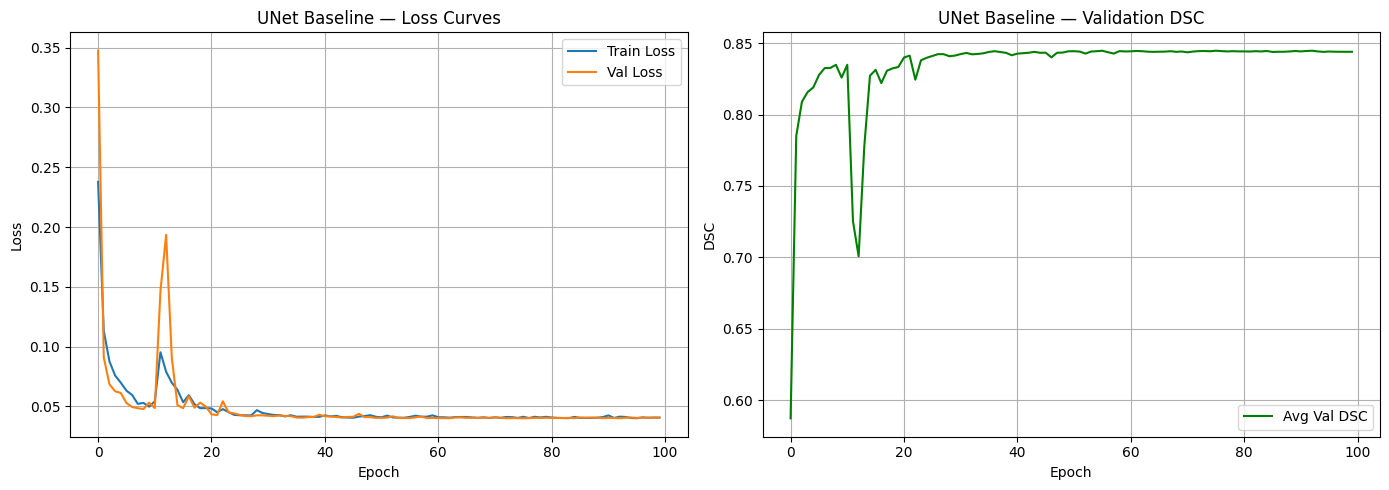

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history["train_loss"], label="Train Loss")
ax1.plot(history["val_loss"], label="Val Loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("UNet Baseline — Loss Curves"); ax1.legend(); ax1.grid(True)

ax2.plot(history["val_dsc"], label="Avg Val DSC", color="green")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("DSC")
ax2.set_title("UNet Baseline — Validation DSC"); ax2.legend(); ax2.grid(True)

plt.tight_layout(); plt.show()

## 9 — Visualise Predictions

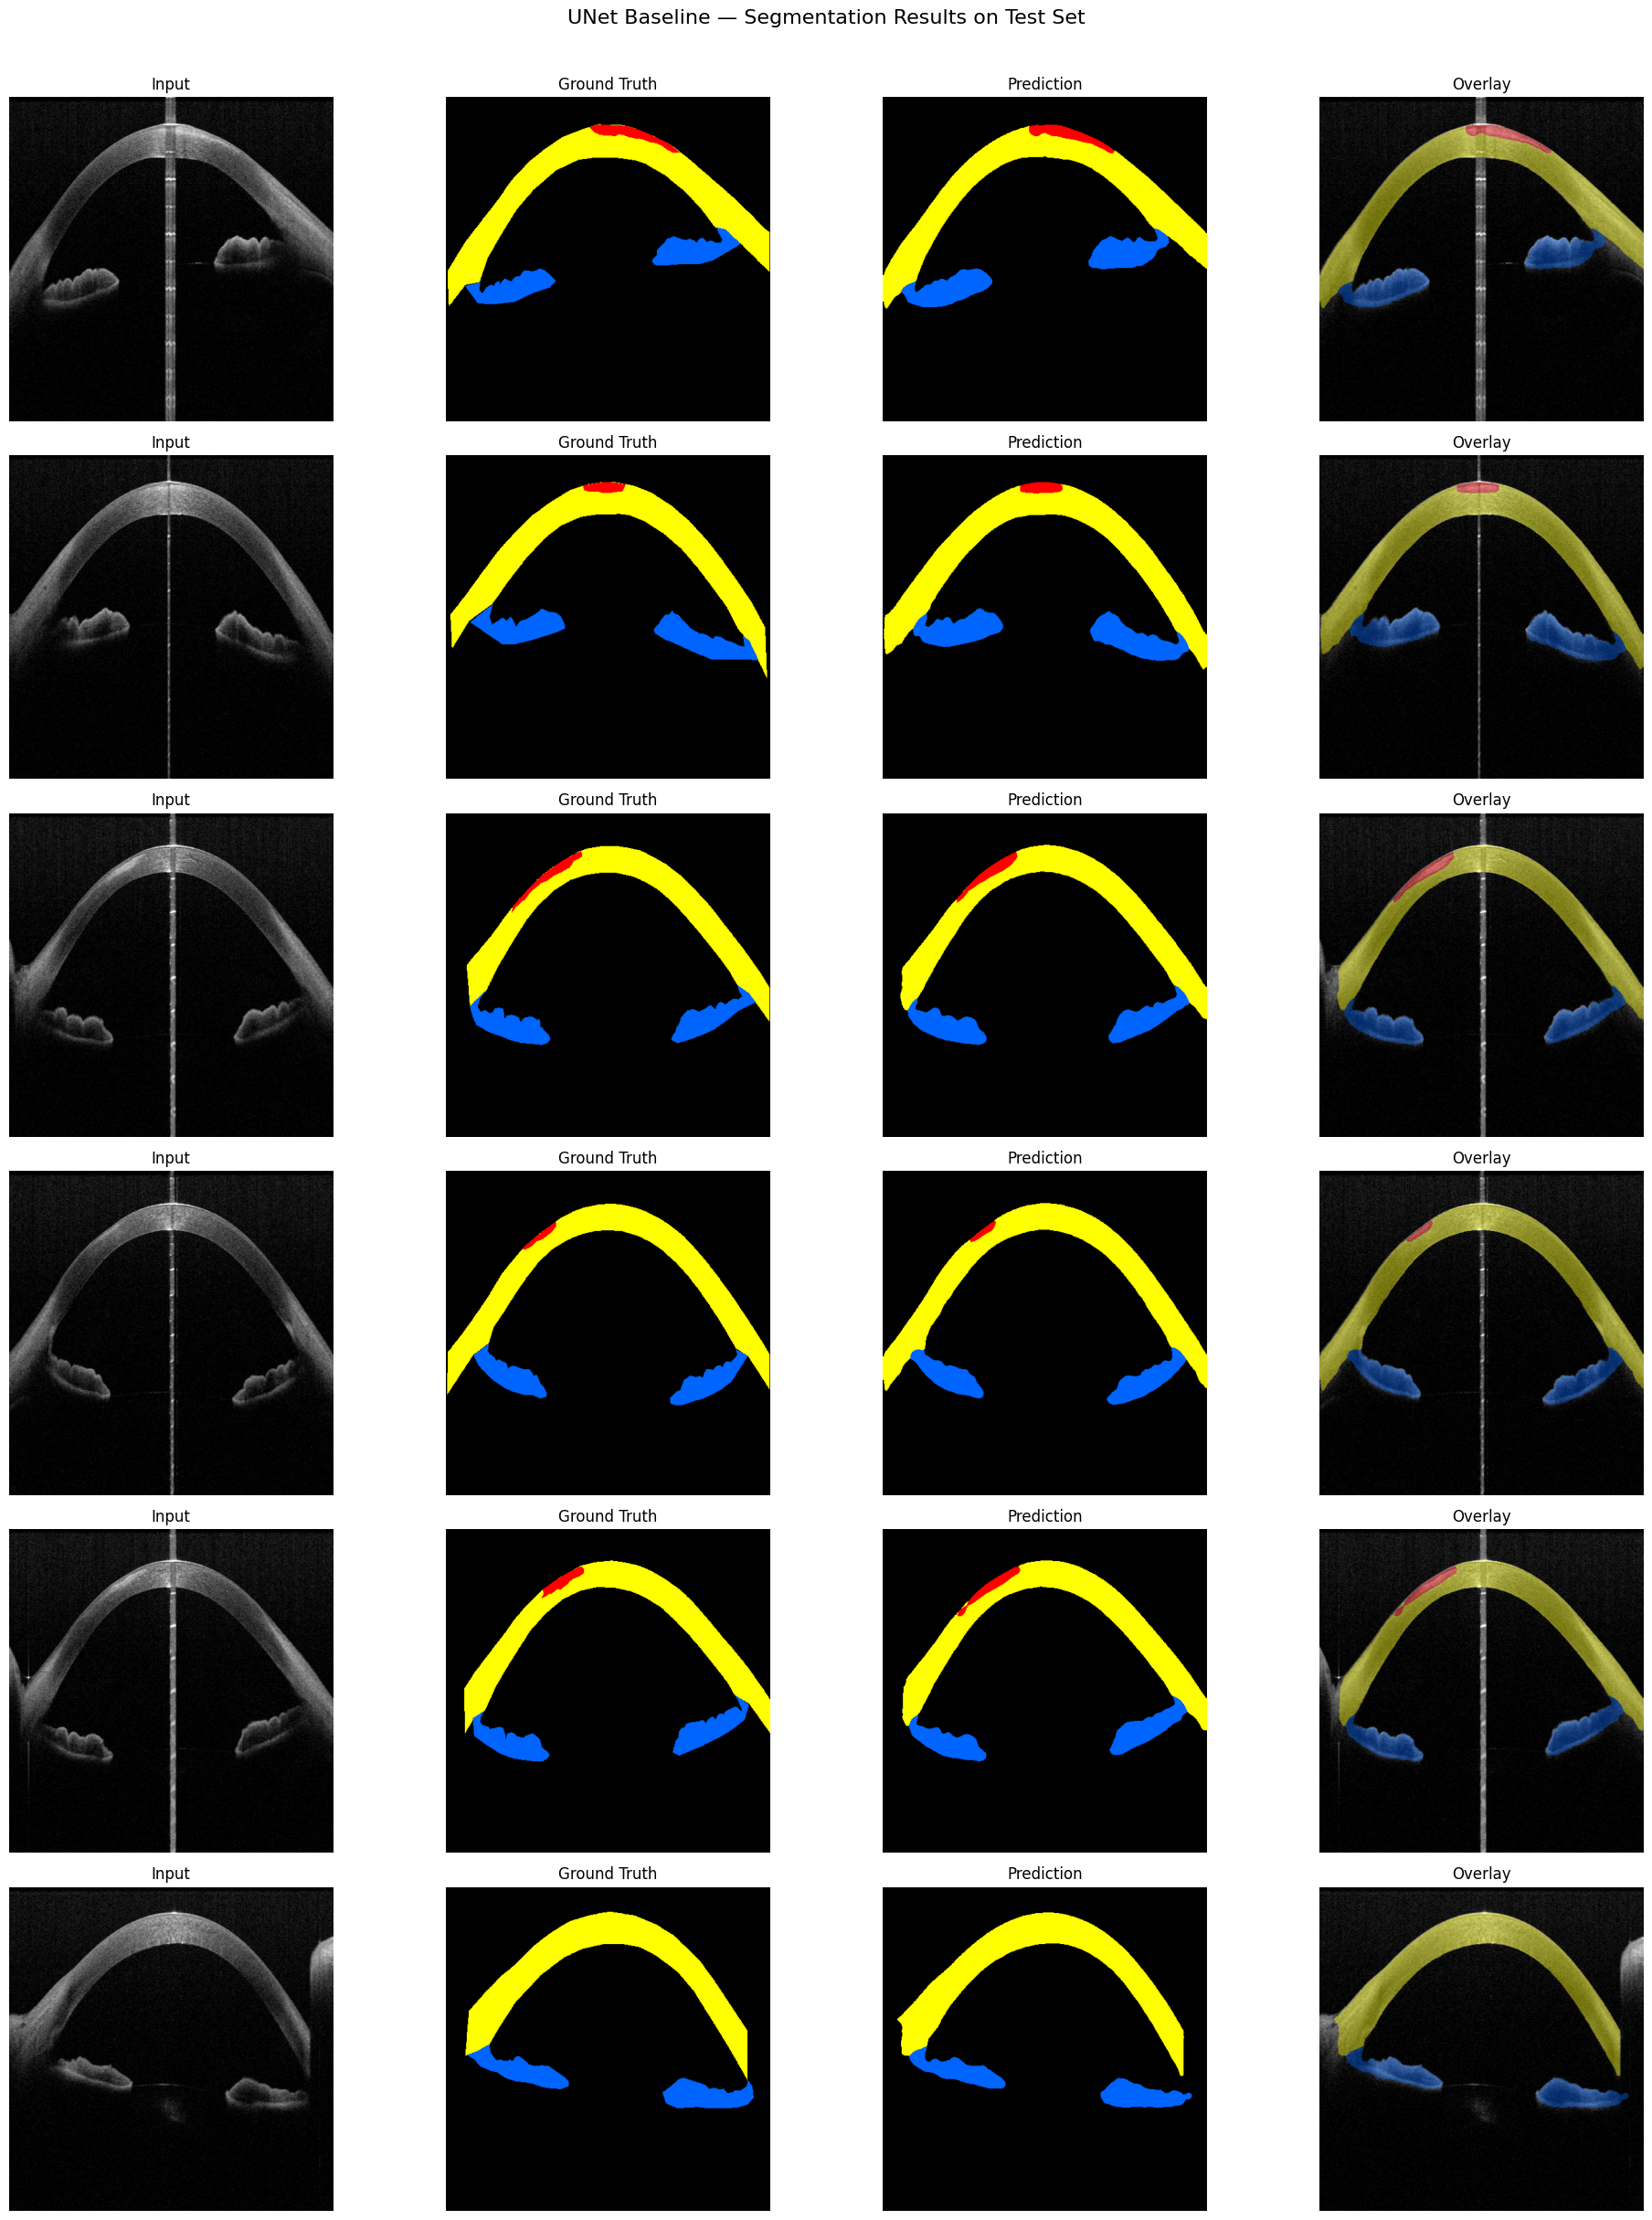

In [20]:
# Colour map for overlay: bg=black, cornea=yellow, lesion=red, iris=blue
COLORS = np.array([
    [0,   0,   0],    # 0: background
    [255, 255, 0],    # 1: cornea
    [255, 0,   0],    # 2: lesion
    [0,   100, 255],  # 3: iris
], dtype=np.uint8)


def mask_to_rgb(mask, alpha=0.4, image=None):
    """Convert class mask to RGB overlay."""
    rgb = COLORS[mask]
    if image is not None:
        img_rgb = (image * 255).astype(np.uint8) if image.max() <= 1 else image
        fg = mask > 0
        blended = img_rgb.copy()
        blended[fg] = (alpha * rgb[fg] + (1 - alpha) * img_rgb[fg]).astype(np.uint8)
        return blended
    return rgb


# Show N random test samples
N_VIS = 6
vis_indices = random.sample(range(len(test_ds)), min(N_VIS, len(test_ds)))

fig, axes = plt.subplots(len(vis_indices), 4, figsize=(20, 4 * len(vis_indices)))
if len(vis_indices) == 1:
    axes = axes[np.newaxis, :]

model.eval()
with torch.no_grad():
    for row, idx in enumerate(vis_indices):
        img_t, seg_gt, bnd_gt = test_ds[idx]
        seg_out = model(img_t.unsqueeze(0).to(DEVICE))
        if seg_out.shape[2:] != seg_gt.shape[:]:
            seg_out = F.interpolate(seg_out, size=seg_gt.shape[:],
                                   mode="bilinear", align_corners=False)
        pred = seg_out.argmax(dim=1)[0].cpu().numpy()
        gt   = seg_gt.numpy()
        img_np = img_t.permute(1, 2, 0).numpy()

        axes[row, 0].imshow(img_np);              axes[row, 0].set_title("Input")
        axes[row, 1].imshow(mask_to_rgb(gt));      axes[row, 1].set_title("Ground Truth")
        axes[row, 2].imshow(mask_to_rgb(pred));    axes[row, 2].set_title("Prediction")
        axes[row, 3].imshow(mask_to_rgb(pred, image=img_np))
        axes[row, 3].set_title("Overlay")
        for c in range(4):
            axes[row, c].axis("off")

plt.suptitle("UNet Baseline — Segmentation Results on Test Set", fontsize=16, y=1.01)
plt.tight_layout(); plt.show()

## 10 — Save / Export Model

In [21]:
# Save full checkpoint with training info
state = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
torch.save({
    "model_state_dict": state,
    "optimizer_state_dict": optimizer.state_dict(),
    "num_classes": NUM_CLASSES,
    "img_size": IMG_SIZE,
    "history": history,
    "config": {
        "model": "ResNet34-UNet (baseline)",
        "batch_size": BATCH_SIZE,
        "init_lr": INIT_LR,
        "include_iris": INCLUDE_IRIS,
        "use_subset": USE_SUBSET,
    }
}, "unet_baseline_checkpoint.pth")

print("Checkpoint saved to unet_baseline_checkpoint.pth")

Checkpoint saved to unet_baseline_checkpoint.pth


---

## ScLNet vs UNet Comparison Reference

After running both notebooks on the **same config**, fill in these results:

| Metric | ScLNet (epoch 67) | UNet Baseline |
|--------|-------------------|---------------|
| Cornea DSC | ~0.97 | ___ |
| Lesion DSC | ~0.67 | ___ |
| Iris DSC | ~0.93 | ___ |
| Total Params | 92.61 M | ___ M |

### What to look for:
- **Lesion DSC** is the critical metric — it's the hardest class and the one that
  benefits most from architectural innovations.
- If ScLNet's lesion DSC significantly exceeds UNet's, the multi-scale pyramid,
  DAC blocks, and boundary decoder are earning their keep.
- Cornea and iris are large, well-defined structures — expect both models to
  perform well on these.

### Notes
- Both models use identical: data splits, augmentations, loss function, optimizer,
  learning rate schedule, and early stopping criteria.
- The only variable is the model architecture.
- For a rigorous comparison, run both models 3x with different seeds and report
  mean +/- std.